In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import os
import sys
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(".."))
df = pd.read_csv('../data/raw/train.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [46]:
df.dtypes.value_counts()

# Separate by type
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Numeric columns ({len(num_cols)}):", num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):", cat_cols)

Numeric columns (38): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', '

In [47]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].round(2)
print(missing_df)

PoolQC          99.52
MiscFeature     96.30
Alley           93.77
Fence           80.75
MasVnrType      59.73
FireplaceQu     47.26
LotFrontage     17.74
GarageQual       5.55
GarageFinish     5.55
GarageType       5.55
GarageYrBlt      5.55
GarageCond       5.55
BsmtFinType2     2.60
BsmtExposure     2.60
BsmtCond         2.53
BsmtQual         2.53
BsmtFinType1     2.53
MasVnrArea       0.55
Electrical       0.07
dtype: float64


Skewness (raw)   : 1.883
Skewness (log1p) : 0.121


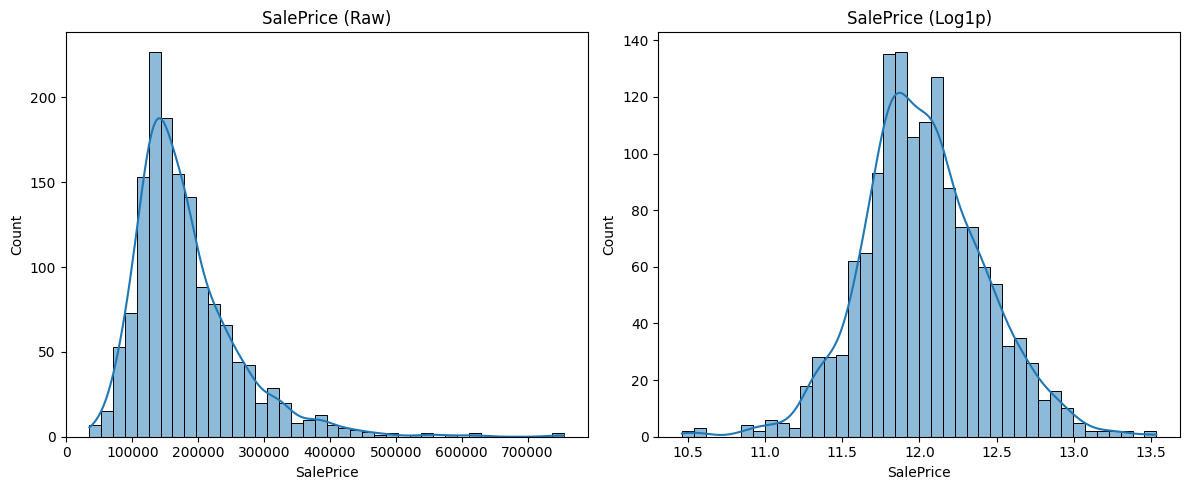

In [48]:

df['SalePrice'].describe().round(2)
print("Skewness (raw)   :", df['SalePrice'].skew().round(3))
print("Skewness (log1p) :", np.log1p(df['SalePrice']).skew().round(3))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['SalePrice'], bins=40, kde=True)
plt.title("SalePrice (Raw)")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['SalePrice']), bins=40, kde=True)
plt.title("SalePrice (Log1p)")

plt.tight_layout()
plt.show()

In [49]:
# Correlation of all numeric features with SalePrice
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()['SalePrice'].drop(['SalePrice', 'Id'])
corr = corr.abs().sort_values(ascending=False)
print(corr.head(20).round(4))

OverallQual     0.7910
GrLivArea       0.7086
GarageCars      0.6404
GarageArea      0.6234
TotalBsmtSF     0.6136
1stFlrSF        0.6059
FullBath        0.5607
TotRmsAbvGrd    0.5337
YearBuilt       0.5229
YearRemodAdd    0.5071
GarageYrBlt     0.4864
MasVnrArea      0.4775
Fireplaces      0.4669
BsmtFinSF1      0.3864
LotFrontage     0.3518
WoodDeckSF      0.3244
2ndFlrSF        0.3193
OpenPorchSF     0.3159
HalfBath        0.2841
LotArea         0.2638
Name: SalePrice, dtype: float64


Highly skewed features (|skew| > 1.0):
MiscVal          24.477
PoolArea         14.828
LotArea          12.208
3SsnPorch        10.304
LowQualFinSF      9.011
KitchenAbvGr      4.488
BsmtFinSF2        4.255
ScreenPorch       4.122
BsmtHalfBath      4.103
EnclosedPorch     3.090
MasVnrArea        2.669
OpenPorchSF       2.364
LotFrontage       2.164
BsmtFinSF1        1.686
WoodDeckSF        1.541
TotalBsmtSF       1.524
MSSubClass        1.408
1stFlrSF          1.377
GrLivArea         1.367
dtype: float64


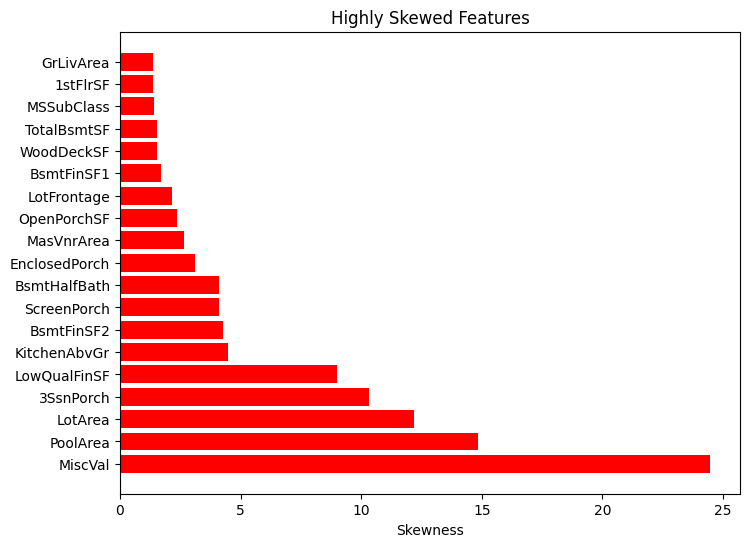

In [50]:
# Skewness of all numeric features
skews = df[num_cols].drop(['Id','SalePrice'], axis=1).skew().sort_values(ascending=False)
skews_high = skews[skews.abs() > 1.0]
print("Highly skewed features (|skew| > 1.0):")
print(skews_high.round(3))
colors = ['red' if x > 0 else 'blue' for x in skews_high]

plt.figure(figsize=(8,6))
plt.barh(skews_high.index, skews_high.values, color=colors)

plt.title("Highly Skewed Features")
plt.xlabel("Skewness")
plt.axvline(0)

plt.show()

In [51]:
for col in cat_cols:
    n_unique = df[col].nunique()
    n_miss = df[col].isnull().sum()
    print(f"{col:20s} unique={n_unique:3d}  missing={n_miss}")

MSZoning             unique=  5  missing=0
Street               unique=  2  missing=0
Alley                unique=  2  missing=1369
LotShape             unique=  4  missing=0
LandContour          unique=  4  missing=0
Utilities            unique=  2  missing=0
LotConfig            unique=  5  missing=0
LandSlope            unique=  3  missing=0
Neighborhood         unique= 25  missing=0
Condition1           unique=  9  missing=0
Condition2           unique=  8  missing=0
BldgType             unique=  5  missing=0
HouseStyle           unique=  8  missing=0
RoofStyle            unique=  6  missing=0
RoofMatl             unique=  8  missing=0
Exterior1st          unique= 15  missing=0
Exterior2nd          unique= 16  missing=0
MasVnrType           unique=  3  missing=872
ExterQual            unique=  4  missing=0
ExterCond            unique=  5  missing=0
Foundation           unique=  6  missing=0
BsmtQual             unique=  4  missing=37
BsmtCond             unique=  4  missing=37
Bsmt

In [52]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Step 1: 60% train, 40% temporary holdout
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

# Step 2: split the 40% holdout evenly -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

total = len(df)
print(f'Train:      {len(X_train):4d} rows  ({len(X_train)/total*100:.0f}%)')
print(f'Validation: {len(X_val):4d} rows  ({len(X_val)/total*100:.0f}%)')
print(f'Test:       {len(X_test):4d} rows  ({len(X_test)/total*100:.0f}%)')
print(f'Total:      {total:4d} rows')

Train:       876 rows  (60%)
Validation:  292 rows  (20%)
Test:        292 rows  (20%)
Total:      1460 rows


In [57]:
# Garage-related columns — are they null on the same rows?
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt', 'GarageArea', 'GarageCars']
garage_null = X_train[garage_cols].isnull()

print('Garage null overlap (number of rows where each pair is BOTH null):')
overlap = garage_null.T.dot(garage_null)
print(overlap)
print(f'\nRows with any garage null: {garage_null.any(axis=1).sum()}')
print(f'Rows with all garage cols null: {garage_null.all(axis=1).sum()}')
print('\nConclusion: garage nulls are co-occurring -> these houses have no garage.')

Garage null overlap (number of rows where each pair is BOTH null):
              GarageType  GarageFinish  GarageQual  GarageCond  GarageYrBlt  \
GarageType          True          True        True        True         True   
GarageFinish        True          True        True        True         True   
GarageQual          True          True        True        True         True   
GarageCond          True          True        True        True         True   
GarageYrBlt         True          True        True        True         True   
GarageArea         False         False       False       False        False   
GarageCars         False         False       False       False        False   

              GarageArea  GarageCars  
GarageType         False       False  
GarageFinish       False       False  
GarageQual         False       False  
GarageCond         False       False  
GarageYrBlt        False       False  
GarageArea         False       False  
GarageCars         False   

In [58]:
# Basement-related columns — same pattern?
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
bsmt_null = X_train[bsmt_cols].isnull()

print('Basement null co-occurrence:')
print(f'Rows where ALL basement quality cols are null: {bsmt_null[["BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]].all(axis=1).sum()}')
print(f'Rows where any basement area col is null:      {bsmt_null[["BsmtFinSF1","TotalBsmtSF"]].any(axis=1).sum()}')
print('\nConclusion: categorical bsmt cols null = no basement -> fill with None / 0.')

Basement null co-occurrence:
Rows where ALL basement quality cols are null: 22
Rows where any basement area col is null:      0

Conclusion: categorical bsmt cols null = no basement -> fill with None / 0.


In [53]:
# Mean SalePrice per category — which cats show strong price signal?
key_cats = ['Neighborhood', 'ExterQual', 'KitchenQual', 'Foundation']
for col in key_cats:
    means = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False).round(0)
    print(f"\n{col}:")
    print(means)


Neighborhood:
Neighborhood
NoRidge    335295.0
NridgHt    316271.0
StoneBr    310499.0
Timber     242247.0
Veenker    238773.0
Somerst    225380.0
ClearCr    212565.0
Crawfor    210625.0
CollgCr    197966.0
Blmngtn    194871.0
Gilbert    192855.0
NWAmes     189050.0
SawyerW    186556.0
Mitchel    156270.0
NAmes      145847.0
NPkVill    142694.0
SWISU      142591.0
Blueste    137500.0
Sawyer     136793.0
OldTown    128225.0
Edwards    128220.0
BrkSide    124834.0
BrDale     104494.0
IDOTRR     100124.0
MeadowV     98576.0
Name: SalePrice, dtype: float64

ExterQual:
ExterQual
Ex    367361.0
Gd    231634.0
TA    144341.0
Fa     87985.0
Name: SalePrice, dtype: float64

KitchenQual:
KitchenQual
Ex    328555.0
Gd    212116.0
TA    139963.0
Fa    105565.0
Name: SalePrice, dtype: float64

Foundation:
Foundation
PConc     225230.0
Wood      185667.0
Stone     165959.0
CBlock    149806.0
BrkTil    132291.0
Slab      107366.0
Name: SalePrice, dtype: float64


In [54]:
# Check for extreme values in GrLivArea vs SalePrice
outliers = df[df['GrLivArea'] > 4000]
print(outliers[['Id', 'GrLivArea', 'OverallQual', 'Neighborhood', 'SalePrice']])

# OverallQual — does price scale monotonically?
qual_price = df.groupby('OverallQual')['SalePrice'].mean().round(0)
print("\nMean price by OverallQual:")
print(qual_price)

        Id  GrLivArea  OverallQual Neighborhood  SalePrice
523    524       4676           10      Edwards     184750
691    692       4316           10      NoRidge     755000
1182  1183       4476           10      NoRidge     745000
1298  1299       5642           10      Edwards     160000

Mean price by OverallQual:
OverallQual
1      50150.0
2      51770.0
3      87474.0
4     108421.0
5     133523.0
6     161603.0
7     207716.0
8     274736.0
9     367513.0
10    438588.0
Name: SalePrice, dtype: float64


In [55]:
candidates = ['OverallQual','GrLivArea','GarageCars','GarageArea',
              'TotalBsmtSF','1stFlrSF','YearBuilt','YearRemodAdd',
              'GarageYrBlt','TotRmsAbvGrd','BsmtFinSF1','2ndFlrSF','LotArea']
corr_matrix = df[candidates].corr().round(2)
print(corr_matrix)

              OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  \
OverallQual          1.00       0.59        0.60        0.56         0.54   
GrLivArea            0.59       1.00        0.47        0.47         0.45   
GarageCars           0.60       0.47        1.00        0.88         0.43   
GarageArea           0.56       0.47        0.88        1.00         0.49   
TotalBsmtSF          0.54       0.45        0.43        0.49         1.00   
1stFlrSF             0.48       0.57        0.44        0.49         0.82   
YearBuilt            0.57       0.20        0.54        0.48         0.39   
YearRemodAdd         0.55       0.29        0.42        0.37         0.29   
GarageYrBlt          0.55       0.23        0.59        0.56         0.32   
TotRmsAbvGrd         0.43       0.83        0.36        0.34         0.29   
BsmtFinSF1           0.24       0.21        0.22        0.30         0.52   
2ndFlrSF             0.30       0.69        0.18        0.14        -0.17   

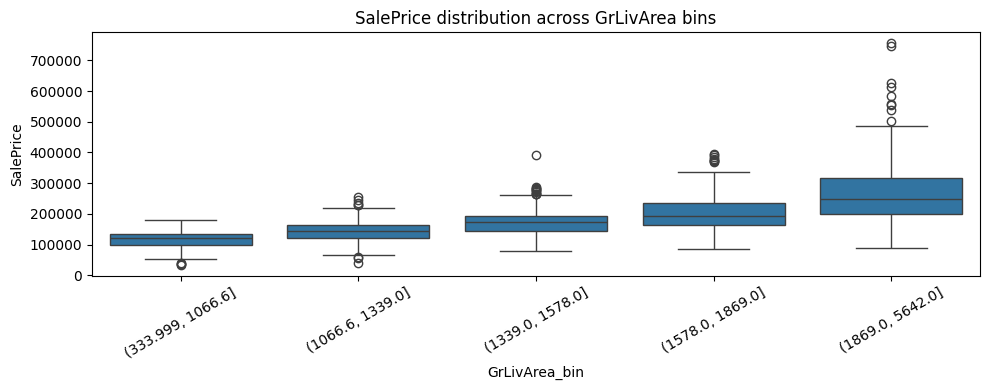

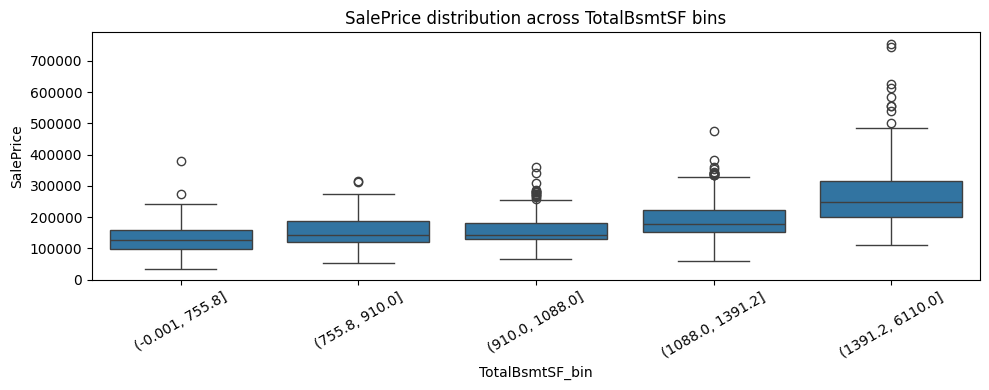

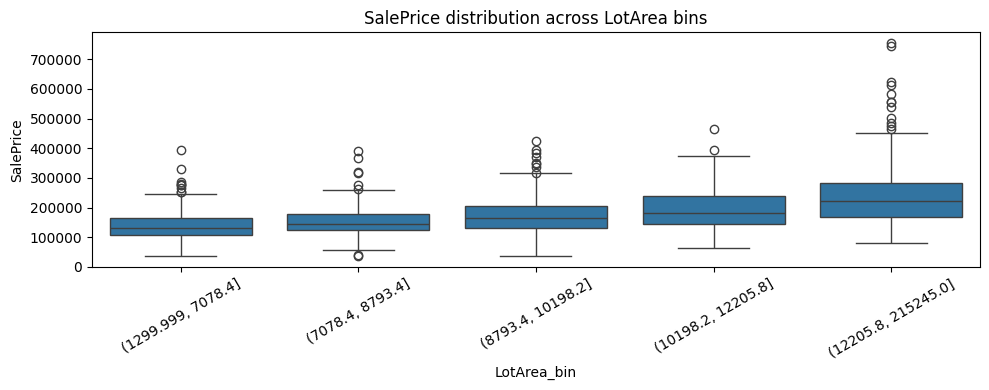

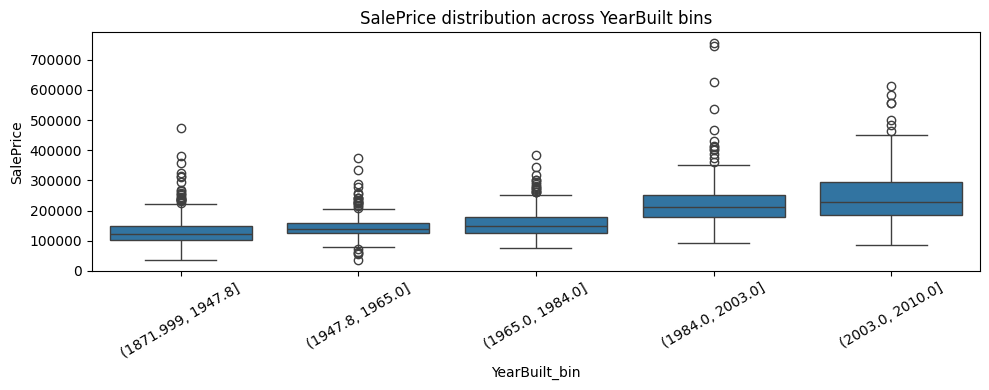

In [59]:
binned_features = ["GrLivArea", "TotalBsmtSF", "LotArea", "YearBuilt"]

for col in binned_features:
    temp = df[[col, "SalePrice"]].copy()
    temp[f"{col}_bin"] = pd.qcut(temp[col], q=5, duplicates="drop")

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=temp, x=f"{col}_bin", y="SalePrice")
    plt.xticks(rotation=30)
    plt.title(f"SalePrice distribution across {col} bins")
    plt.tight_layout()
    plt.show()

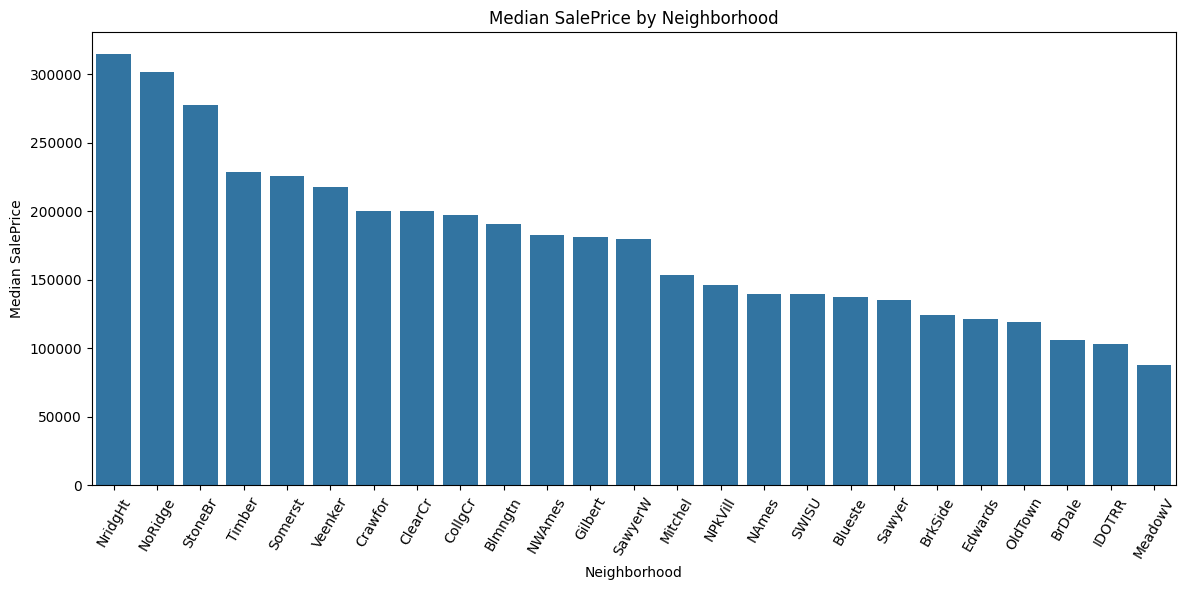

(                median  count
 Neighborhood                 
 NridgHt       315000.0     77
 NoRidge       301500.0     41
 StoneBr       278000.0     25
 Timber        228475.0     38
 Somerst       225500.0     86
 Veenker       218000.0     11
 Crawfor       200624.0     51
 ClearCr       200250.0     28
 CollgCr       197200.0    150
 Blmngtn       191000.0     17,
                 median  count
 Neighborhood                 
 NAmes         140000.0    225
 SWISU         139500.0     25
 Blueste       137500.0      2
 Sawyer        135000.0     74
 BrkSide       124300.0     58
 Edwards       121750.0    100
 OldTown       119000.0    113
 BrDale        106000.0     16
 IDOTRR        103000.0     37
 MeadowV        88000.0     17)

In [60]:
neigh_stats = (
    df.groupby("Neighborhood")["SalePrice"]
      .agg(["median", "count"])
      .sort_values("median", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=neigh_stats.index, y=neigh_stats["median"])
plt.xticks(rotation=60)
plt.title("Median SalePrice by Neighborhood")
plt.ylabel("Median SalePrice")
plt.tight_layout()
plt.show()

neigh_stats.head(10), neigh_stats.tail(10)

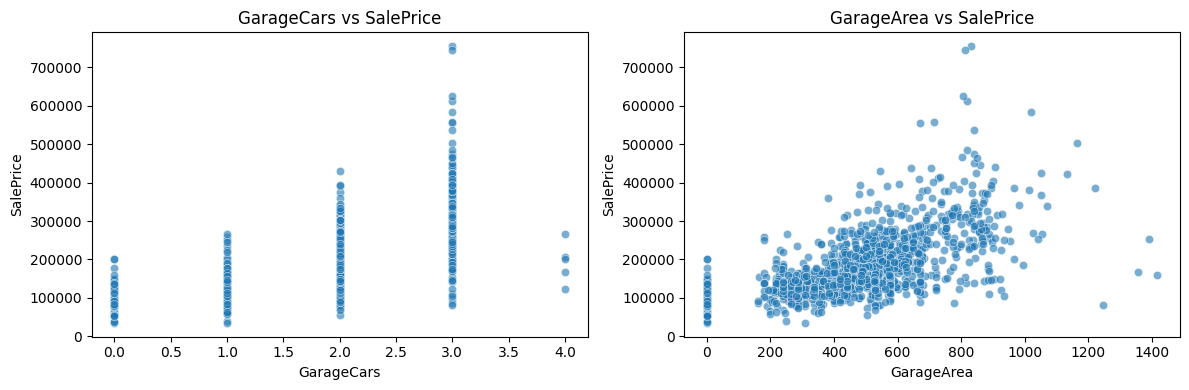

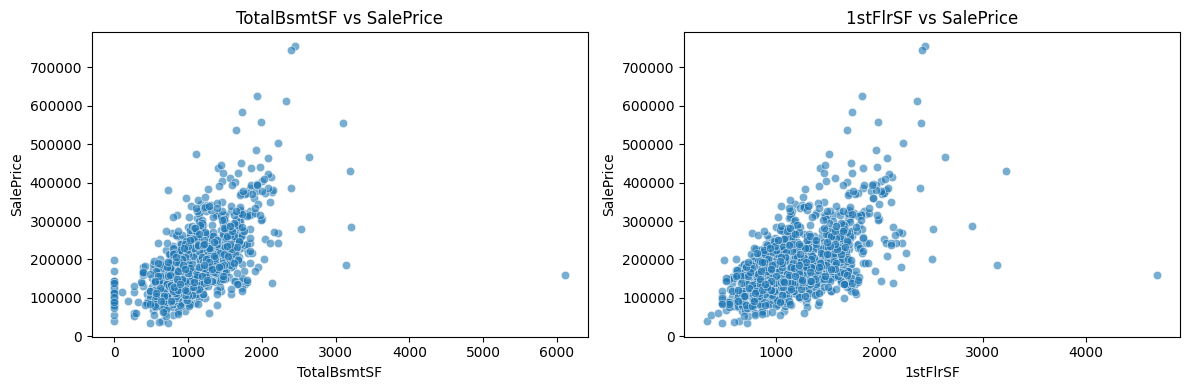

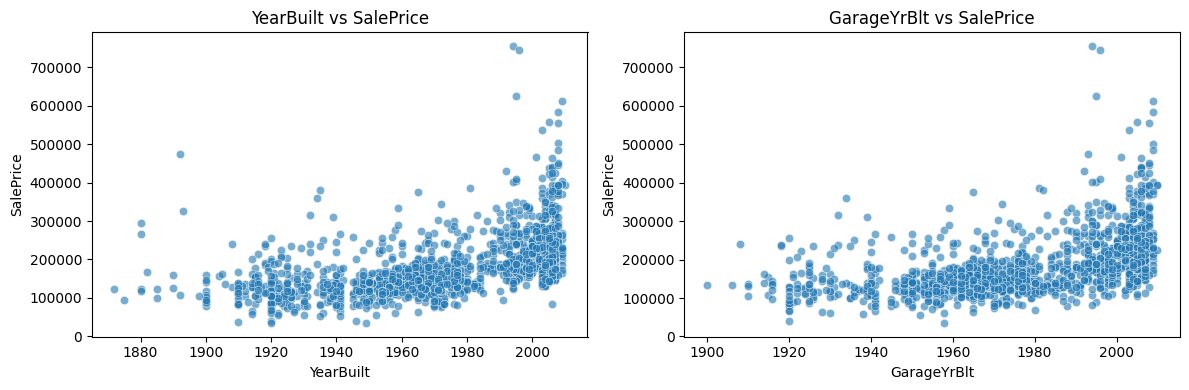

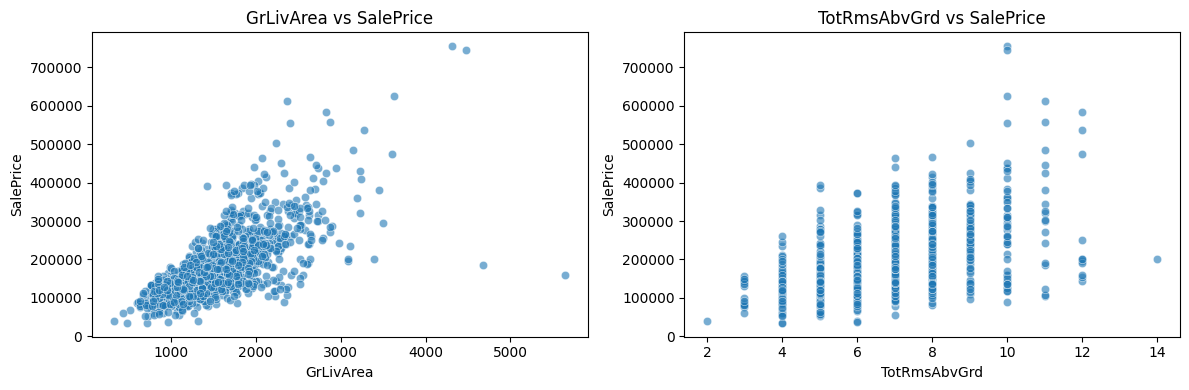

In [61]:
competitor_pairs = [
    ("GarageCars", "GarageArea"),
    ("TotalBsmtSF", "1stFlrSF"),
    ("YearBuilt", "GarageYrBlt"),
    ("GrLivArea", "TotRmsAbvGrd"),
]

for keep_col, drop_col in competitor_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.scatterplot(data=df, x=keep_col, y="SalePrice", ax=axes[0], alpha=0.6)
    axes[0].set_title(f"{keep_col} vs SalePrice")

    sns.scatterplot(data=df, x=drop_col, y="SalePrice", ax=axes[1], alpha=0.6)
    axes[1].set_title(f"{drop_col} vs SalePrice")

    plt.tight_layout()
    plt.show()

In [66]:
selected_features = [
    'OverallQual',
    'GrLivArea',
    'YearBuilt',
    'Neighborhood',
    'TotalBsmtSF',
    'GarageCars',
    'FullBath',
    'LotArea',
    'BedroomAbvGr',
    'HouseStyle'
]

In [72]:
df[selected_features].isnull().sum().sort_values(ascending=False)

OverallQual     0
GrLivArea       0
YearBuilt       0
Neighborhood    0
TotalBsmtSF     0
GarageCars      0
FullBath        0
LotArea         0
BedroomAbvGr    0
HouseStyle      0
dtype: int64

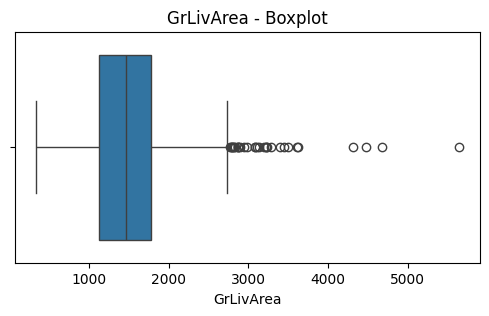

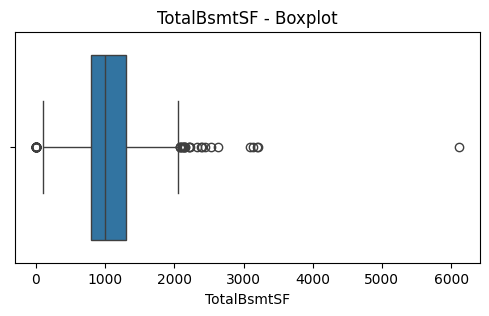

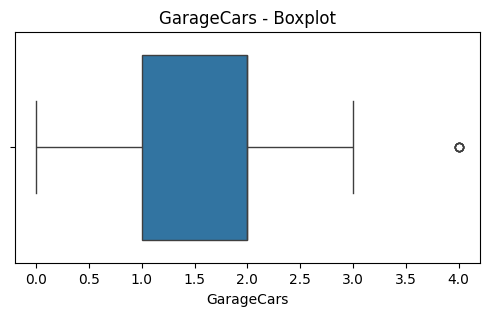

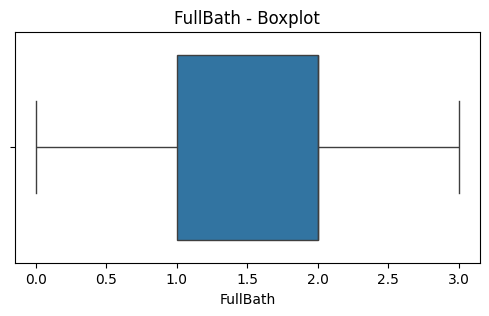

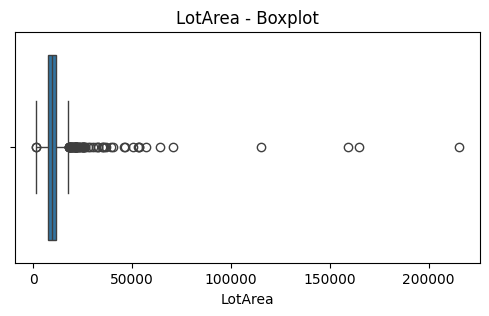

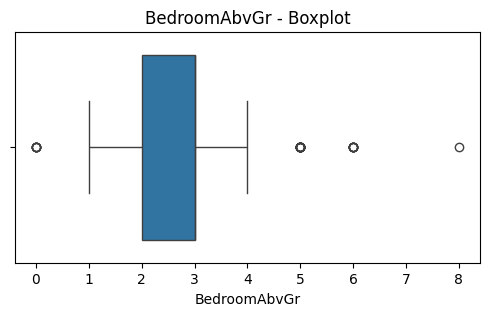

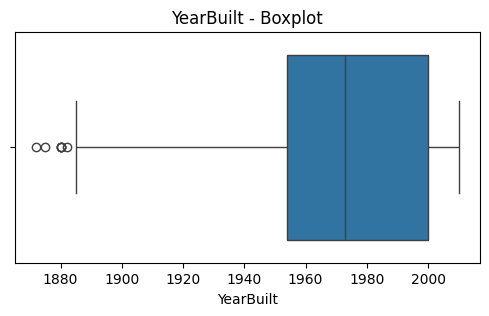

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    'FullBath', 'LotArea', 'BedroomAbvGr', 'YearBuilt'
]

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Boxplot")
    plt.show()

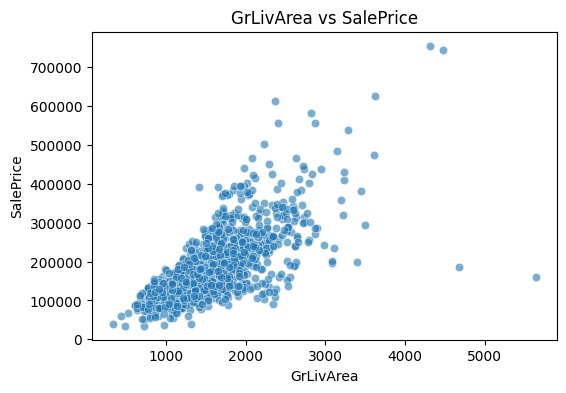

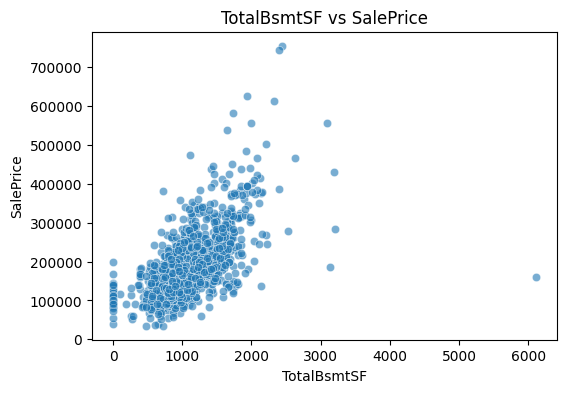

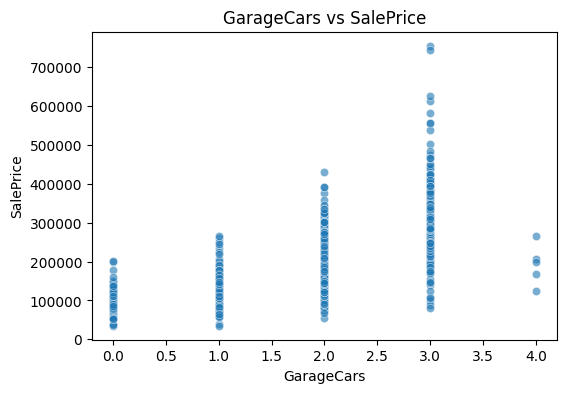

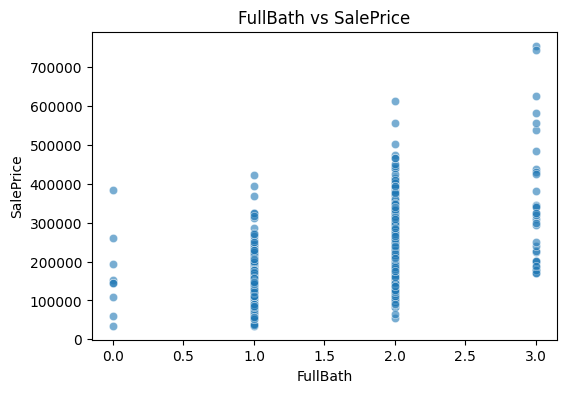

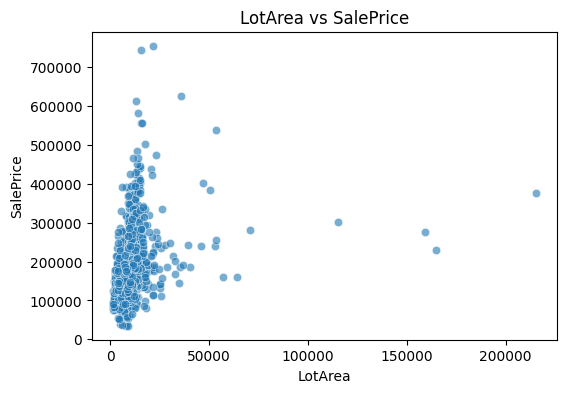

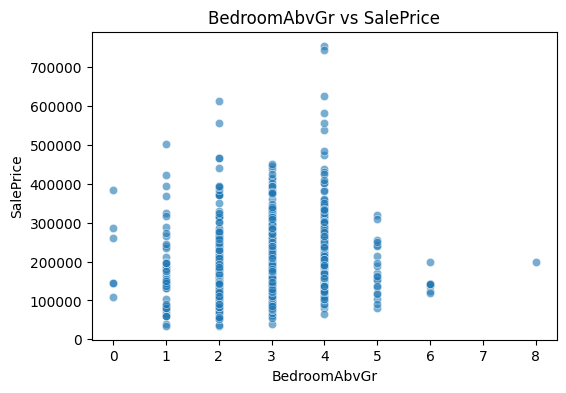

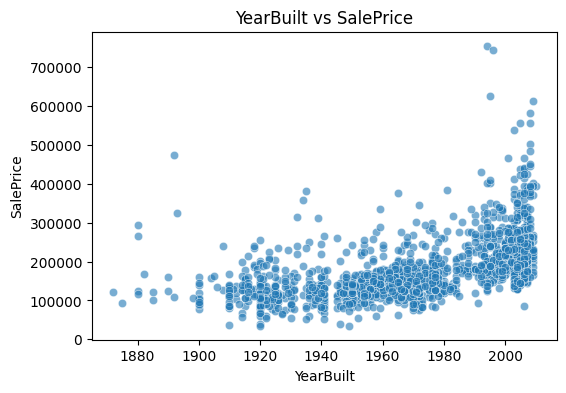

In [74]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y="SalePrice", alpha=0.6)
    plt.title(f"{col} vs SalePrice")
    plt.show()

In [68]:
cat_cols = ['Neighborhood', 'HouseStyle']

for col in cat_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


Neighborhood unique values:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

HouseStyle unique values:
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64


In [69]:
for col in cat_cols:
    print(col, "→", df[col].nunique())

Neighborhood → 25
HouseStyle → 8


In [70]:
df[selected_features].describe()

,OverallQual,GrLivArea,YearBuilt,TotalBsmtSF,GarageCars,FullBath,LotArea,BedroomAbvGr
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1971.267808,1057.429452,1.767123,1.565068,10516.828082,2.866438
std,1.382997,525.480383,30.202904,438.705324,0.747315,0.550916,9981.264932,0.815778
min,1.000000,334.000000,1872.000000,0.000000,0.000000,0.000000,1300.000000,0.000000
25%,5.000000,1129.500000,1954.000000,795.750000,1.000000,1.000000,7553.500000,2.000000
50%,6.000000,1464.000000,1973.000000,991.500000,2.000000,2.000000,9478.500000,3.000000
75%,7.000000,1776.750000,2000.000000,1298.250000,2.000000,2.000000,11601.500000,3.000000
max,10.000000,5642.000000,2010.000000,6110.000000,4.000000,3.000000,215245.000000,8.000000


In [71]:
for col in df[selected_features].select_dtypes(include='number').columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

OverallQual: 2 outliers
GrLivArea: 31 outliers
YearBuilt: 7 outliers
TotalBsmtSF: 61 outliers
GarageCars: 5 outliers
FullBath: 0 outliers
LotArea: 69 outliers
BedroomAbvGr: 35 outliers
